# Feature Engineering

## 1. Setup

We have learnt that our dataset has a mix of categorical and numerical features, specifically bool target variable. There are also 8 float64. 8 int64, and 3 str data types. 

The dataset has no missing values, which means there is no need for imputation or dropping columns. 

The target variable `Churn` is a boolean variable with True and False values. The distribution of the target variable is not balanced, with a higher proportion of False values compared to True values. This indicates that we may need to consider techniques for handling class imbalance during modeling.

For variable correlation, we have observed that the following numerical features are highly correlated with each other:
* Total day charge & Total day minutes
* Total eve charge & Total eve minutes
* Total night charge & Total night minutes
* Total intl charge & Total intl minutes

This means that we can select only one of either of the correlated features to avoid multicollinearity in our model. With this, we choose to drop the following features: `Total day charge`, `Total eve charge`, `Total night charge`, and `Total intl charge`.

### 1.1 Install Dependencies

In [13]:
# Import modules
import numpy as np 
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

Set up the working directory by setting the paths to the data, then **import the training & testing datasets**.

In [14]:
from pathlib import Path

TRAINING_DATA_NAME = "churn-bigml-80.csv"
TESTING_DATA_NAME = "churn-bigml-20.csv"
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
train_data = pd.read_csv(DATA_DIR / TRAINING_DATA_NAME)
test_data = pd.read_csv(DATA_DIR / TESTING_DATA_NAME)
print(f"Train data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")

Train data shape: (2666, 20)
Test data shape: (667, 20)


## 2. Data preprocessing

In [15]:
TARGET = 'Churn'

# Remove correlated features
col_to_drop = ['Total day charge', 'Total eve charge', 'Total night charge', 'Total intl charge']
train_data = train_data.drop(columns=col_to_drop)
test_data = test_data.drop(columns=col_to_drop)

In [16]:
# Identify categorical features
cat_cols = train_data.select_dtypes(include=['object']).columns.tolist()
print(f"Unique values in each column:\n{train_data[cat_cols].nunique()}")

train_data[cat_cols].head()

Unique values in each column:
State                 51
International plan     2
Voice mail plan        2
dtype: int64


,State,International plan,Voice mail plan
0,KS,No,Yes
1,OH,No,Yes
2,NJ,No,No
3,OH,Yes,No
4,OK,Yes,No


We can see that `International plan` and `Voice mail plan` are categorical features with Yes/No values. We will encode these features into binary values (1 for Yes, 0 for No) using binary mapping. We will also do the same for the testing dataset to ensure consistency in our feature engineering process. Our target variable `Churn` is in binary format, but we will also encode it into binary values (1 for True, 0 for False) to ensure consistency in our feature engineering process.

For the variable `State`, we will leave it as is for now as we will be using the feature importance from our baseline model to determine if it is a significant feature to include in our final model. If it is not significant, we will drop it from the dataset.

In [17]:
to_encode = ['International plan', 'Voice mail plan']

binary_map = {'Yes': 1, 'No': 0}
for col in to_encode:
    train_data[col] = train_data[col].map(binary_map)
    test_data[col] = test_data[col].map(binary_map)

binary_map_target = {True: 1, False: 0}
train_data[TARGET] = train_data[TARGET].map(binary_map_target)
test_data[TARGET] = test_data[TARGET].map(binary_map_target)

train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   str    
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   int64  
 4   Voice mail plan         2666 non-null   int64  
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total eve minutes       2666 non-null   float64
 9   Total eve calls         2666 non-null   int64  
 10  Total night minutes     2666 non-null   float64
 11  Total night calls       2666 non-null   int64  
 12  Total intl minutes      2666 non-null   float64
 13  Total intl calls        2666 non-null   int64  
 14  Customer service calls  2666 non-null   int64  
 15

To double check for collinearity, we will create a correlation matrix to visualize the relationships between the features. This will help us identify any additional features that may be highly correlated and should be dropped from the dataset.

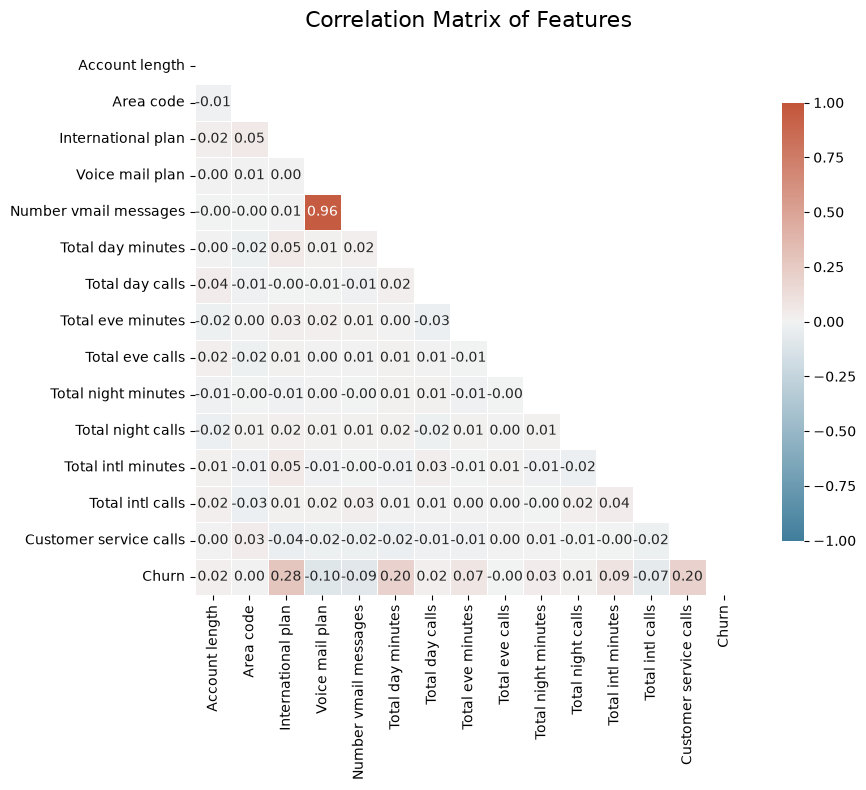

In [18]:
# Make a correlation matrix to visualize the correlation between features

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

corr = train_data.select_dtypes(include='number').corr(method='pearson')
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 8))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr,
    mask=mask,
    cmap=cmap,
    vmax=1.0, vmin=-1.0,
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix of Features", fontsize=16, pad=15)
plt.tight_layout()
plt.show()

We can see that `Number vmail messages` is highly correlated with `Voice mail plan`, which makes sense as the number of voice mail messages is dependent on whether the customer has a voice mail plan or not. Therefore, we will drop the `Voice mail plan` feature from the dataset and keep the numerical `Number vmail messages` feature.

Also, we have observed that `Area code` and `State` are fields that store the same information, as each area code corresponds to a specific state. Therefore, we will drop the `Area code` feature from the dataset and keep the `State` feature.

In [19]:
from scipy.stats import chi2_contingency

# 1. Create a contingency table (cross tabulation)
contigency_matrix = pd.crosstab(train_data[TARGET], train_data['State'])

# 2. Perform the Chi-Square test of independence
chi2, p_val, dof, expected = chi2_contingency(contigency_matrix)

# 3. Calculate Cramér's V statistic
n = contigency_matrix.sum().sum() # Total number of observations
min_dim = min(contigency_matrix.shape) - 1 # Minimum dimension of the contingency table
cramers_v = np.sqrt(chi2 / (n * min_dim))

# Output the results
print(f"Chi-Square Statistic for 'State' & 'Churn': {chi2:.2f}")
print(f"P-value: {p_val:.4e}")
print(f"Cramér's V: {cramers_v:.4f}")

Chi-Square Statistic for 'State' & 'Churn': 79.80
P-value: 4.6807e-03
Cramér's V: 0.1730


In [20]:
from sklearn.feature_selection import mutual_info_classif

state_encoded = train_data['State'].astype('category').cat.codes.to_frame()
churn_target = train_data[TARGET].astype('int')

mi_score = mutual_info_classif(state_encoded, churn_target, discrete_features=True, random_state=SEED)[0]
print(f"Mutual Information Score for 'State': {mi_score:.4f}")


Mutual Information Score for 'State': 0.0150


In [21]:
to_drop = ['Voice mail plan']

train_data = train_data.drop(columns=to_drop)
test_data = test_data.drop(columns=to_drop)

In [22]:
test_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 667 entries, 0 to 666
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   667 non-null    str    
 1   Account length          667 non-null    int64  
 2   Area code               667 non-null    int64  
 3   International plan      667 non-null    int64  
 4   Number vmail messages   667 non-null    int64  
 5   Total day minutes       667 non-null    float64
 6   Total day calls         667 non-null    int64  
 7   Total eve minutes       667 non-null    float64
 8   Total eve calls         667 non-null    int64  
 9   Total night minutes     667 non-null    float64
 10  Total night calls       667 non-null    int64  
 11  Total intl minutes      667 non-null    float64
 12  Total intl calls        667 non-null    int64  
 13  Customer service calls  667 non-null    int64  
 14  Churn                   667 non-null    int64  
dtype

In [23]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   str    
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   int64  
 4   Number vmail messages   2666 non-null   int64  
 5   Total day minutes       2666 non-null   float64
 6   Total day calls         2666 non-null   int64  
 7   Total eve minutes       2666 non-null   float64
 8   Total eve calls         2666 non-null   int64  
 9   Total night minutes     2666 non-null   float64
 10  Total night calls       2666 non-null   int64  
 11  Total intl minutes      2666 non-null   float64
 12  Total intl calls        2666 non-null   int64  
 13  Customer service calls  2666 non-null   int64  
 14  Churn                   2666 non-null   int64  
dty

Since we have already chosen features to drop based on correlation and dropped them from the dataset, we will now split the dataset into features and target variable for both training and testing datasets. We will then save these datasets as CSV files for future use in modeling.

In [24]:
X_train = train_data.drop(columns=[TARGET])
y_train = train_data[TARGET]

X_test = test_data.drop(columns=[TARGET])
y_test = test_data[TARGET]

X_train.to_csv(PROCESSED_DIR / "X_train.csv", index=False)
X_test.to_csv(PROCESSED_DIR / "X_test.csv", index=False)
y_train.to_csv(PROCESSED_DIR / "y_train.csv", index=False)
y_test.to_csv(PROCESSED_DIR / "y_test.csv", index=False)